<a href="https://colab.research.google.com/github/shumailas709/Data-Analytic-Portfolio-/blob/main/Project9_Autocomplete_Autocorrect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ================================
# Project 9 - Autocomplete &
# Autocorrect Data Analytics
# Dataset: NLTK Corpus
# ================================

import nltk
nltk.download('gutenberg')
nltk.download('punkt')
nltk.download('words')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from nltk.corpus import gutenberg, words
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")


[nltk_data] Downloading package gutenberg to /root/nltk_data...
[nltk_data]   Unzipping corpora/gutenberg.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


All libraries loaded successfully!


In [ ]:
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# ================================
# Step 2 - Load & Explore Data
# ================================

# Load text data
text = gutenberg.raw('austen-emma.txt')
tokens = nltk.word_tokenize(text.lower())

# Only keep alphabetic words
tokens = [w for w in tokens if w.isalpha()]

print(f"Total words: {len(tokens)}")
print(f"Unique words: {len(set(tokens))}")
print(f"\nSample words: {tokens[:20]}")

# Word frequency
word_freq = Counter(tokens)
print(f"\nTop 10 words: {word_freq.most_common(10)}")


Total words: 157110
Unique words: 6932

Sample words: ['emma', 'by', 'jane', 'austen', 'volume', 'i', 'chapter', 'i', 'emma', 'woodhouse', 'handsome', 'clever', 'and', 'rich', 'with', 'a', 'comfortable', 'home', 'and', 'happy']

Top 10 words: [('the', 5201), ('to', 5181), ('and', 4877), ('of', 4284), ('i', 3177), ('a', 3124), ('it', 2503), ('her', 2448), ('was', 2396), ('she', 2336)]


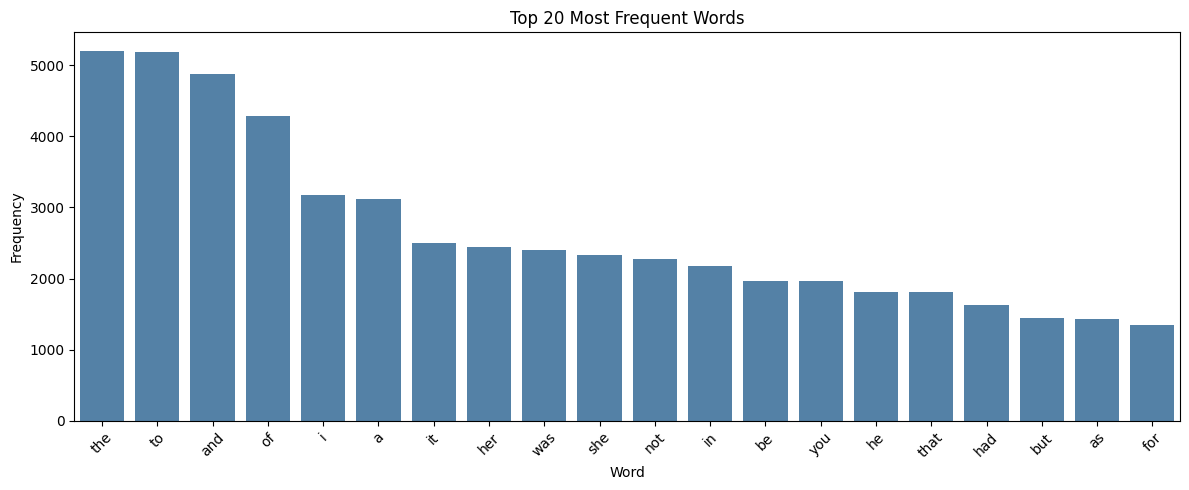

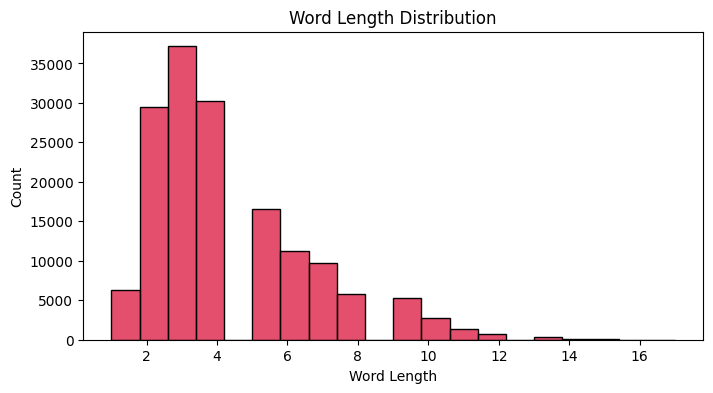

Plots ready!


In [ ]:
# ================================
# Step 3 - Visualizations
# ================================

# Plot 1: Top 20 Most Common Words
top_words = pd.DataFrame(word_freq.most_common(20),
                          columns=['Word', 'Count'])

plt.figure(figsize=(12, 5))
sns.barplot(x='Word', y='Count', data=top_words, color='steelblue')
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 2: Word Length Distribution
word_lengths = [len(w) for w in tokens]
plt.figure(figsize=(8, 4))
sns.histplot(word_lengths, bins=20, color='crimson')
plt.title('Word Length Distribution')
plt.xlabel('Word Length')
plt.ylabel('Count')
plt.show()

print("Plots ready!")


In [ ]:
# ================================
# Step 4 - Autocomplete Algorithm
# ================================

# Bigram model - next word predict karo
bigrams = list(nltk.bigrams(tokens))
bigram_freq = Counter(bigrams)

# Autocomplete function
def autocomplete(prefix, n=5):
    suggestions = {word2: freq for (word1, word2), freq
                   in bigram_freq.items() if word1 == prefix}
    sorted_suggestions = sorted(suggestions.items(),
                                key=lambda x: x[1], reverse=True)
    return [word for word, freq in sorted_suggestions[:n]]

# Test karo
test_words = ['good', 'every', 'time', 'man', 'great']
print("Autocomplete Suggestions:")
print("="*40)
for word in test_words:
    suggestions = autocomplete(word)
    print(f"'{word}' -> {suggestions}")


Autocomplete Suggestions:
'good' -> ['deal', 'and', 'sense', 'to', 'fortune']
'every' -> ['thing', 'body', 'day', 'other', 'moment']
'time' -> ['to', 'of', 'for', 'and', 'she']
'man' -> ['and', 'of', 'who', 'in', 'but']
'great' -> ['deal', 'pleasure', 'a', 'many', 'regard']


In [ ]:
# ================================
# Step 5 - Autocorrect Algorithm
# ================================

from nltk.corpus import words
english_words = set(words.words())

def edit_distance(w1, w2):
    m, n = len(w1), len(w2)
    dp = [[0]*(n+1) for _ in range(m+1)]
    for i in range(m+1):
        for j in range(n+1):
            if i == 0: dp[i][j] = j
            elif j == 0: dp[i][j] = i
            elif w1[i-1] == w2[j-1]: dp[i][j] = dp[i-1][j-1]
            else: dp[i][j] = 1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])
    return dp[m][n]

def autocorrect(word, n=3):
    if word in english_words:
        return f"'{word}' is correct!"
    candidates = [w for w in english_words if abs(len(w)-len(word)) <= 2]
    scored = sorted(candidates, key=lambda w: edit_distance(word, w))
    return scored[:n]

# Test
test_typos = ['speling', 'wrold', 'hte', 'recieve']
print("Autocorrect Suggestions:")
print("="*40)
for typo in test_typos:
    print(f"'{typo}' -> {autocorrect(typo)}")


Autocorrect Suggestions:
'speling' -> ['spelling', 'apeling', 'spelding']
'wrold' -> ['woold', 'wold', 'woad']
'hte' -> ['hie', 'hue', 'Ute']
'recieve' -> ['relieve', 'relive', 'believe']


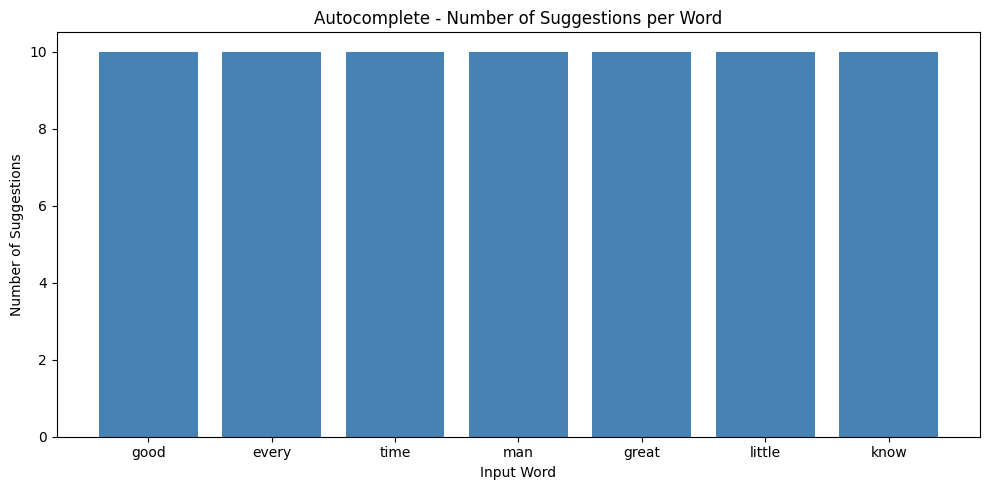

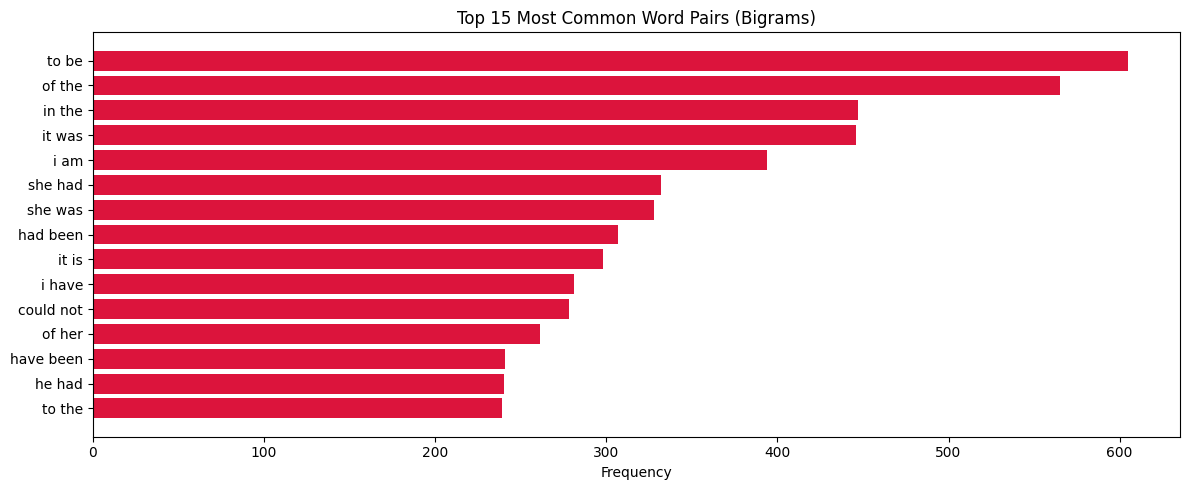

Project Complete!


In [ ]:
# ================================
# Step 6 - Final Visualization
# ================================

# Plot: Autocomplete suggestions count
test_words = ['good', 'every', 'time', 'man', 'great', 'little', 'know']
suggestion_counts = [len(autocomplete(w, n=10)) for w in test_words]

plt.figure(figsize=(10, 5))
plt.bar(test_words, suggestion_counts, color='steelblue')
plt.title('Autocomplete - Number of Suggestions per Word')
plt.xlabel('Input Word')
plt.ylabel('Number of Suggestions')
plt.tight_layout()
plt.show()

# Plot: Top Bigrams
top_bigrams = Counter(bigrams).most_common(15)
bigram_labels = [f"{a} {b}" for (a,b),_ in top_bigrams]
bigram_counts = [c for _,c in top_bigrams]

plt.figure(figsize=(12, 5))
plt.barh(bigram_labels, bigram_counts, color='crimson')
plt.title('Top 15 Most Common Word Pairs (Bigrams)')
plt.xlabel('Frequency')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Project Complete!")
